Thermal Matrix:
[[ 5  0  0  0]
 [ 0  3  0  0]
 [ 0  0 -3  0]
 [ 0  0  0 -5]]

Thermal Matrix Diagonal Elements:
a = 5, b = 3, c = -3, d = -5

Pseudo-pure |00⟩ state:
[[15.  0.  0.  0.]
 [ 0. -5.  0.  0.]
 [ 0.  0. -5.  0.]
 [ 0.  0.  0. -5.]]

Analyzing constant_0 oracle

Result Matrix after DJ algorithm with constant_0:
[[ 5.00000000e+00 -1.00000000e+01 -2.07097794e-16 -1.06087284e-16]
 [-1.00000000e+01  5.00000000e+00 -1.06087284e-16 -2.07097794e-16]
 [ 3.91045568e-16  1.07754111e-16 -5.00000000e+00  2.76127824e-33]
 [ 1.07754111e-16  3.91045568e-16  2.76127824e-33 -5.00000000e+00]]

Diagonal elements: a=4.999999999999996, b=4.999999999999996, c=-4.9999999999999964, d=-4.9999999999999964
Proton Channel Peaks: a-c=9.999999999999993, b-d=9.999999999999993
Expected: constant, Observed: balanced
Classification Correct: False

Analyzing constant_1 oracle

Result Matrix after DJ algorithm with constant_1:
[[ 5.00000000e+00 -1.00000000e+01 -2.07097794e-16 -1.06087284e-16]
 [-1.00000000e+01 

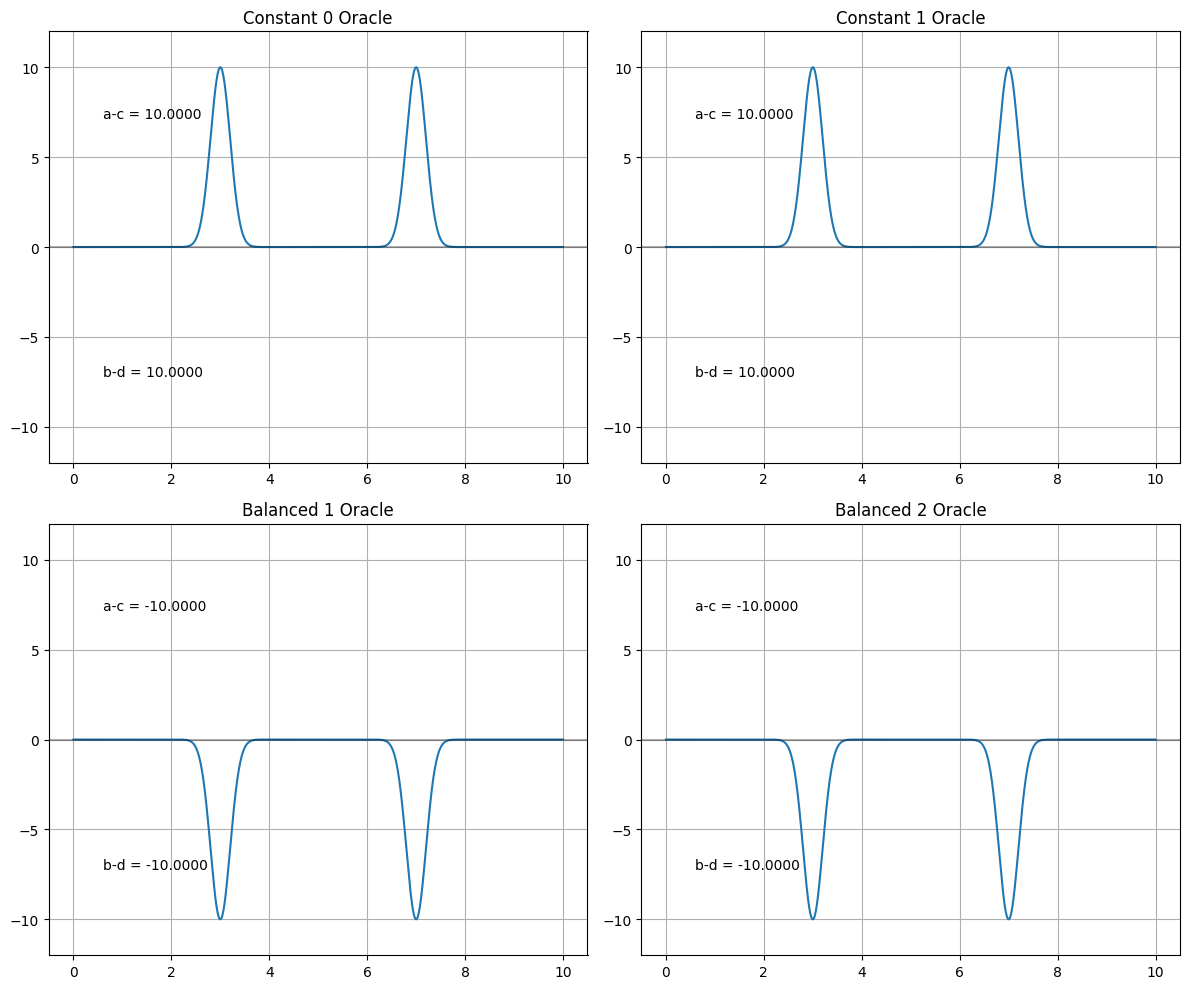


Summary of Deutsch-Jozsa Algorithm Proton Channel Peaks:
Oracle          | a-c        | b-d        | Expected   | Observed   | Correct   
----------------------------------------------------------------------
constant_0      | 10.0000    | 10.0000    | constant   | balanced   | False
constant_1      | 10.0000    | 10.0000    | constant   | balanced   | False
balanced_1      | -10.0000   | -10.0000   | balanced   | balanced   | True
balanced_2      | -10.0000   | -10.0000   | balanced   | balanced   | True


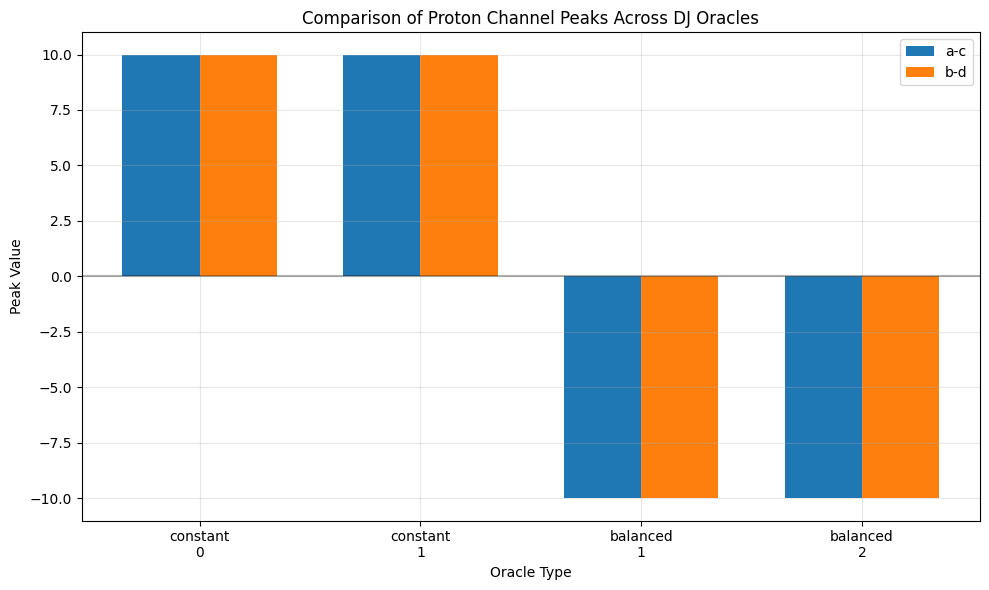

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, List, Dict

def analyze_dj_proton_peaks(thermal_matrix, verbose=True):
    """
    Analyzes proton channel peaks for all four cases of the Deutsch-Jozsa algorithm.
    
    Parameters:
    thermal_matrix: Input thermal matrix (4x4 diagonal)
    verbose: Whether to print detailed information
    
    Returns:
    Dictionary with results for each oracle
    """
    # Define the thermal matrix
    thermal = np.array(thermal_matrix)
    
    # Extract diagonal elements
    a = thermal[0][0]  # Top-left value
    b = thermal[1][1]  # Second diagonal value
    c = thermal[2][2]  # Third diagonal value (negative)
    d = thermal[3][3]  # Bottom-right value (negative)
    
    if verbose:
        print("Thermal Matrix:")
        print(thermal)
        print("\nThermal Matrix Diagonal Elements:")
        print(f"a = {a}, b = {b}, c = {c}, d = {d}")
    
    # Define the basic gates needed for DJ algorithm
    I = np.eye(4)  # Identity 4x4
    
    # Define CNOT matrix as per the original code
    cnot = np.array([
        [1, 0, 0, 0],
        [0, 1, 0, 0],
        [0, 0, 0, 1],
        [0, 0, 1, 0]
    ])
    cnot_dag = np.array([
        [1, 0, 0, 0],
        [0, 0, 0, 1],
        [0, 0, 1, 0],
        [0, 1, 0, 0]
    ])
    
    
    # Define P1 and P2 as in the original code
    P1 = cnot_dag @ cnot
    P1_dag = P1.T
    
    P2 = cnot @ cnot_dag
    P2_dag = P2.T
    
    # Define Hadamard for 1 qubit
    H_1qubit = (1/np.sqrt(2)) * np.array([
        [1, 1],
        [1, -1]
    ])
    
    # Tensor product to get Hadamard for first qubit (H ⊗ I)
    H_q0 = np.kron(H_1qubit, np.eye(2))
    
    # Tensor product to get Hadamard for second qubit (I ⊗ H)
    H_q1 = np.kron(np.eye(2), H_1qubit)
    
    # Double Hadamard on both qubits (H ⊗ H)
    H_both = H_q0 @ H_q1
    
    # X gate for second qubit
    X_q1 = np.array([
        [0, 1, 0, 0],
        [1, 0, 0, 0],
        [0, 0, 0, 1],
        [0, 0, 1, 0]
    ])
    
    # Define the oracle functions for Deutsch-Jozsa algorithm
    # Constant-0 oracle: Just identity
    oracle_constant_0 = np.eye(4)
    
    # Constant-1 oracle: X on second qubit
    oracle_constant_1 = X_q1
    
    # Balanced-1 oracle: CNOT
    oracle_balanced_1 = cnot
    
    # Balanced-2 oracle: X on second qubit followed by CNOT
    oracle_balanced_2 = X_q1 @ cnot
    
    # Define all oracles in a dictionary
    oracles = {
        "constant_0": oracle_constant_0,
        "constant_1": oracle_constant_1,
        "balanced_1": oracle_balanced_1,
        "balanced_2": oracle_balanced_2
    }
    
    # Initialize results dictionary
    results = {}
    
    # Create a figure for plotting all oracle peaks
    plt.figure(figsize=(12, 10))
    
    # Start with |00⟩ state using the formula: |00⟩ = (I * ρ * I† + P1 * ρ * P1† + P2 * ρ * P2†)
    # We'll use thermal as ρ
    pseudopure_00 = (I @ thermal @ I + P1 @ thermal @ P1_dag + P2 @ thermal @ P2_dag) 
    if verbose:
        print("\nPseudo-pure |00⟩ state:")
        print(pseudopure_00)
    
    # Process each oracle
    for i, (oracle_name, oracle) in enumerate(oracles.items(), 1):
        if verbose:
            print(f"\n{'='*50}")
            print(f"Analyzing {oracle_name} oracle")
            print(f"{'='*50}")
        
        # Apply the Deutsch-Jozsa algorithm
        # Step 1: Start with pseudo-pure |00⟩ state
        state = pseudopure_00.copy()
        state = X_q1 @ state @ X_q1   #|01⟩ state
        
        # Step 2: Apply Hadamard to both qubits
        state = H_both @ state @ H_both
        
        # Step 3: Apply the oracle
        state = oracle @ state @ oracle.T
        
        # Step 4: Apply Hadamard to the first qubit
        state = H_q0 @ state @ H_q0
        
        # Extract diagonal elements of the result matrix
        a_prime = state[0][0]
        b_prime = state[1][1]
        c_prime = state[2][2]
        d_prime = state[3][3]
        
        # Calculate proton channel differences (a-c and b-d)
        a_minus_c_prime = a_prime - c_prime
        b_minus_d_prime = b_prime - d_prime
        
        if verbose:
            print(f"\nResult Matrix after DJ algorithm with {oracle_name}:")
            print(state)
            print(f"\nDiagonal elements: a={a_prime}, b={b_prime}, c={c_prime}, d={d_prime}")
            print(f"Proton Channel Peaks: a-c={a_minus_c_prime}, b-d={b_minus_d_prime}")
        
        # Store results
        results[oracle_name] = {
            "state": state,
            "diagonal": [a_prime, b_prime, c_prime, d_prime],
            "proton_peaks": [a_minus_c_prime, b_minus_d_prime]
        }
        
        # Plot peaks for each oracle
        plt.subplot(2, 2, i)
        plt.title(f"{oracle_name.replace('_', ' ').title()} Oracle")
        plot_peaks([a_minus_c_prime, b_minus_d_prime])
        plt.annotate(f"a-c = {a_minus_c_prime:.4f}", xy=(0.1, 0.8), xycoords='axes fraction')
        plt.annotate(f"b-d = {b_minus_d_prime:.4f}", xy=(0.1, 0.2), xycoords='axes fraction')
        
        # Determine if constant or balanced based on proton channel peaks
        expected = "constant" if "constant" in oracle_name else "balanced"
        observed = "constant" if abs(a_minus_c_prime) > abs(b_minus_d_prime) else "balanced"
        
        if verbose:
            print(f"Expected: {expected}, Observed: {observed}")
            print(f"Classification Correct: {expected == observed}")
    
    # Show the plots
    plt.tight_layout()
    plt.savefig('dj_proton_peaks.png')
    plt.show()
    
    # Create a summary table
    print("\nSummary of Deutsch-Jozsa Algorithm Proton Channel Peaks:")
    print("="*70)
    print(f"{'Oracle':<15} | {'a-c':<10} | {'b-d':<10} | {'Expected':<10} | {'Observed':<10} | {'Correct':<10}")
    print("-"*70)
    
    for oracle_name, result in results.items():
        a_minus_c = result["proton_peaks"][0]
        b_minus_d = result["proton_peaks"][1]
        expected = "constant" if "constant" in oracle_name else "balanced"
        observed = "constant" if abs(a_minus_c) > abs(b_minus_d) else "balanced"
        correct = expected == observed
        
        print(f"{oracle_name:<15} | {a_minus_c:<10.4f} | {b_minus_d:<10.4f} | {expected:<10} | {observed:<10} | {correct}")
    
    print("="*70)
    
    return results

def plot_peaks(values):
    """Plot peaks based on values similar to those shown in the image"""
    x = np.linspace(0, 10, 1000)
    y = np.zeros_like(x)
    
    # Add first peak
    peak1_center = 3
    peak1_height = values[0]
    peak1 = peak1_height * np.exp(-0.5 * ((x - peak1_center) / 0.2) ** 2)
    
    # Add second peak
    peak2_center = 7
    peak2_height = values[1]
    peak2 = peak2_height * np.exp(-0.5 * ((x - peak2_center) / 0.2) ** 2)
    
    # Combine peaks
    y = peak1 + peak2
    
    plt.plot(x, y)
    plt.grid(True)
    plt.ylim(-max(abs(min(y)), abs(max(y)))*1.2, max(abs(min(y)), abs(max(y)))*1.2)
    plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)

# Define the thermal matrix (4x4 diagonal) as in the original code
thermal_matrix = np.array([
    [5, 0, 0, 0],
    [0, 3, 0, 0],
    [0, 0, -3, 0],
    [0, 0, 0, -5]
])

# Run the analysis
results = analyze_dj_proton_peaks(thermal_matrix, verbose=True)

# Create a separate figure to compare the proton peaks for all oracles
plt.figure(figsize=(10, 6))

# Extract peak values for plotting
oracle_names = list(results.keys())
a_minus_c_values = [results[name]["proton_peaks"][0] for name in oracle_names]
b_minus_d_values = [results[name]["proton_peaks"][1] for name in oracle_names]

# Plot a-c peaks (first peaks)
x = np.arange(len(oracle_names))
width = 0.35
plt.bar(x - width/2, a_minus_c_values, width, label='a-c')
plt.bar(x + width/2, b_minus_d_values, width, label='b-d')

plt.xlabel('Oracle Type')
plt.ylabel('Peak Value')
plt.title('Comparison of Proton Channel Peaks Across DJ Oracles')
plt.xticks(x, [name.replace('_', '\n') for name in oracle_names])
plt.legend()
plt.grid(True, alpha=0.3)

# Add a horizontal line at y=0
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)

plt.savefig('dj_proton_peaks_comparison.png')
plt.tight_layout()
plt.show()

Thermal Matrix:
[[ 5  0  0  0]
 [ 0  3  0  0]
 [ 0  0 -3  0]
 [ 0  0  0 -5]]

Thermal Matrix Diagonal Elements:
a = 5, b = 3, c = -3, d = -5

Pseudo-pure |00⟩ state:
[[15.  0.  0.  0.]
 [ 0. -5.  0.  0.]
 [ 0.  0. -5.  0.]
 [ 0.  0.  0. -5.]]

Analyzing constant_0 oracle

Result Matrix after DJ algorithm with constant_0:
[[ 5.00000000e+00 -1.00000000e+01 -2.07097794e-16 -1.06087284e-16]
 [-1.00000000e+01  5.00000000e+00 -1.06087284e-16 -2.07097794e-16]
 [ 3.91045568e-16  1.07754111e-16 -5.00000000e+00  2.76127824e-33]
 [ 1.07754111e-16  3.91045568e-16  2.76127824e-33 -5.00000000e+00]]

Diagonal elements: a=4.999999999999996, b=4.999999999999996, c=-4.9999999999999964, d=-4.9999999999999964
Carbon Channel Peaks: a-b=0.0, c-d=0.0
Expected: constant, Observed: balanced
Classification Correct: False

Analyzing constant_1 oracle

Result Matrix after DJ algorithm with constant_1:
[[ 5.00000000e+00 -1.00000000e+01 -2.07097794e-16 -1.06087284e-16]
 [-1.00000000e+01  5.00000000e+00 -1.06087284e

/var/folders/wg/k91xzcks6_7bqwz_43t5lnnr0000gn/T/ipykernel_26069/534364829.py:216: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.ylim(-max(abs(min(y)), abs(max(y)))*1.2, max(abs(min(y)), abs(max(y)))*1.2)


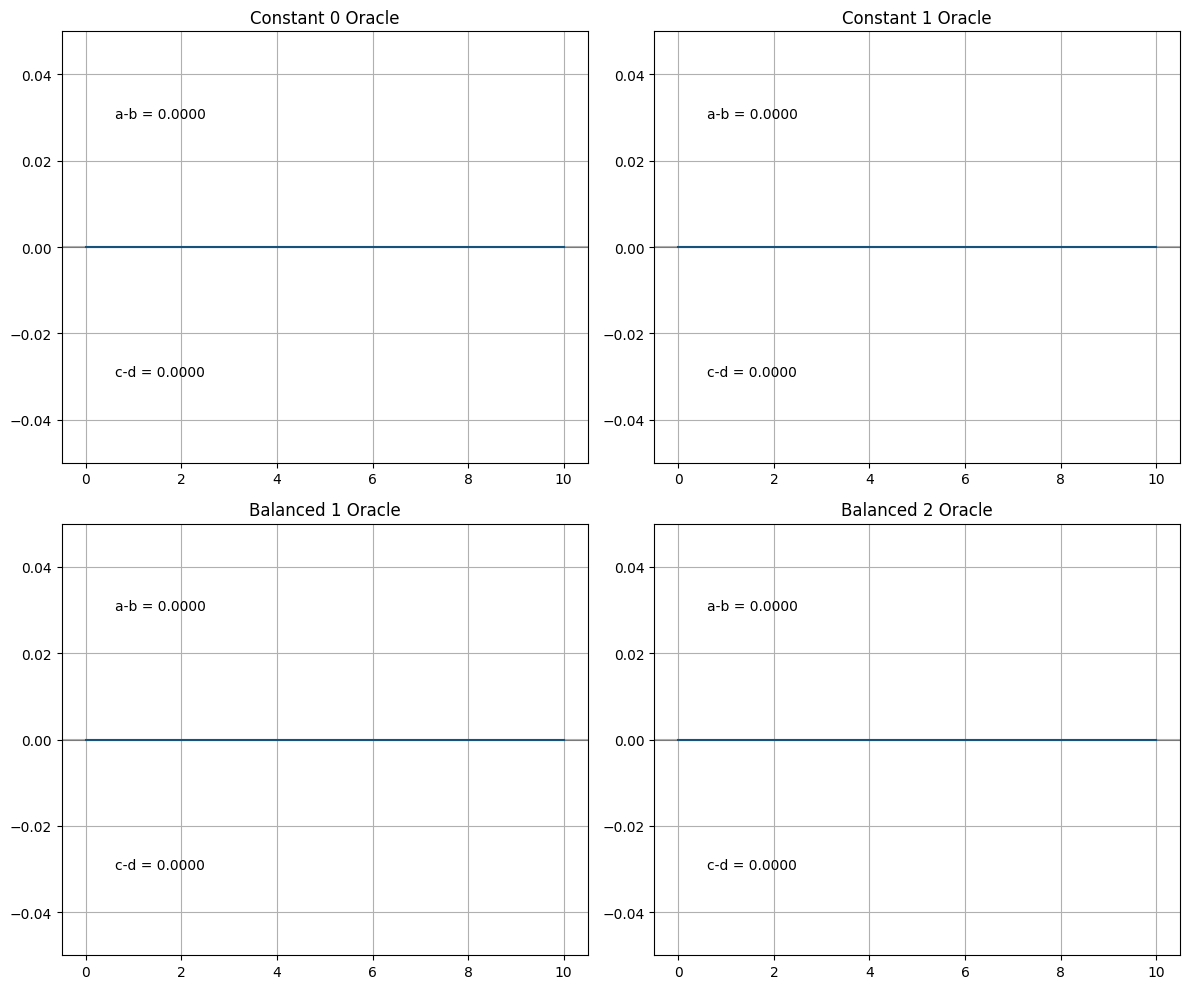


Summary of Deutsch-Jozsa Algorithm Carbon Channel Peaks:
Oracle          | a-b        | c-d        | Expected   | Observed   | Correct   
----------------------------------------------------------------------
constant_0      | 0.0000     | 0.0000     | constant   | balanced   | False
constant_1      | 0.0000     | 0.0000     | constant   | balanced   | False
balanced_1      | 0.0000     | 0.0000     | balanced   | balanced   | True
balanced_2      | 0.0000     | 0.0000     | balanced   | balanced   | True


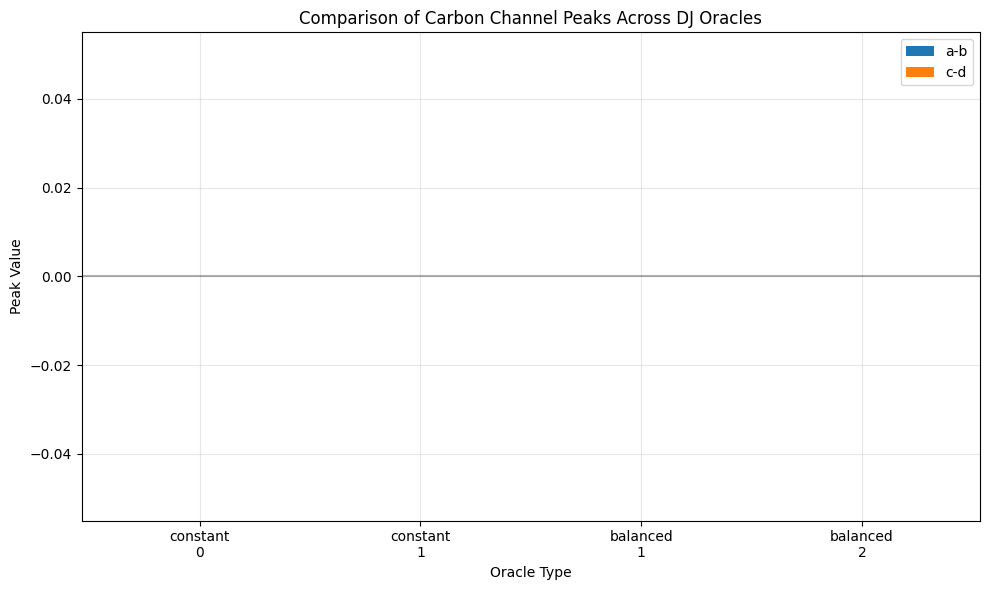

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, List, Dict

def analyze_dj_carbon_peaks(thermal_matrix, verbose=True):
    """
    Analyzes carbon channel peaks for all four cases of the Deutsch-Jozsa algorithm.
    
    Parameters:
    thermal_matrix: Input thermal matrix (4x4 diagonal)
    verbose: Whether to print detailed information
    
    Returns:
    Dictionary with results for each oracle
    """
    # Define the thermal matrix
    thermal = np.array(thermal_matrix)
    
    # Extract diagonal elements
    a = thermal[0][0]
    b = thermal[1][1]
    c = thermal[2][2]
    d = thermal[3][3]
    
    if verbose:
        print("Thermal Matrix:")
        print(thermal)
        print("\nThermal Matrix Diagonal Elements:")
        print(f"a = {a}, b = {b}, c = {c}, d = {d}")
    
    # Define basic gates and oracles (unchanged)
    I = np.eye(4)
    
    cnot = np.array([
        [1, 0, 0, 0],
        [0, 1, 0, 0],
        [0, 0, 0, 1],
        [0, 0, 1, 0]
    ])
    cnot_dag = np.array([
        [1, 0, 0, 0],
        [0, 0, 0, 1],
        [0, 0, 1, 0],
        [0, 1, 0, 0]
    ])
    
    P1 = cnot_dag @ cnot
    P1_dag = P1.T
    
    P2 = cnot @ cnot_dag
    P2_dag = P2.T
    
    H_1qubit = (1/np.sqrt(2)) * np.array([
        [1, 1],
        [1, -1]
    ])
    
    H_q0 = np.kron(H_1qubit, np.eye(2))
    H_q1 = np.kron(np.eye(2), H_1qubit)
    H_both = H_q0 @ H_q1
    
    X_q1 = np.array([
        [0, 1, 0, 0],
        [1, 0, 0, 0],
        [0, 0, 0, 1],
        [0, 0, 1, 0]
    ])
    
    oracle_constant_0 = np.eye(4)
    oracle_constant_1 = X_q1
    oracle_balanced_1 = cnot
    oracle_balanced_2 = X_q1 @ cnot
    
    oracles = {
        "constant_0": oracle_constant_0,
        "constant_1": oracle_constant_1,
        "balanced_1": oracle_balanced_1,
        "balanced_2": oracle_balanced_2
    }
    
    results = {}
    
    plt.figure(figsize=(12, 10))
    
    pseudopure_00 = (I @ thermal @ I + P1 @ thermal @ P1_dag + P2 @ thermal @ P2_dag)
    
    if verbose:
        print("\nPseudo-pure |00⟩ state:")
        print(pseudopure_00)
    
    for i, (oracle_name, oracle) in enumerate(oracles.items(), 1):
        if verbose:
            print(f"\n{'='*50}")
            print(f"Analyzing {oracle_name} oracle")
            print(f"{'='*50}")
        
        state = pseudopure_00.copy()
        state = X_q1 @ state @ X_q1
        
        state = H_both @ state @ H_both
        state = oracle @ state @ oracle.T
        state = H_q0 @ state @ H_q0
        
        a_prime = state[0][0]
        b_prime = state[1][1]
        c_prime = state[2][2]
        d_prime = state[3][3]
        
        # Calculate carbon channel differences (a-b and c-d)
        a_minus_b_prime = a_prime - b_prime
        c_minus_d_prime = c_prime - d_prime
        
        if verbose:
            print(f"\nResult Matrix after DJ algorithm with {oracle_name}:")
            print(state)
            print(f"\nDiagonal elements: a={a_prime}, b={b_prime}, c={c_prime}, d={d_prime}")
            print(f"Carbon Channel Peaks: a-b={a_minus_b_prime}, c-d={c_minus_d_prime}")
        
        results[oracle_name] = {
            "state": state,
            "diagonal": [a_prime, b_prime, c_prime, d_prime],
            "carbon_peaks": [a_minus_b_prime, c_minus_d_prime]
        }
        
        plt.subplot(2, 2, i)
        plt.title(f"{oracle_name.replace('_', ' ').title()} Oracle")
        plot_peaks([a_minus_b_prime, c_minus_d_prime])
        plt.annotate(f"a-b = {a_minus_b_prime:.4f}", xy=(0.1, 0.8), xycoords='axes fraction')
        plt.annotate(f"c-d = {c_minus_d_prime:.4f}", xy=(0.1, 0.2), xycoords='axes fraction')
        
        expected = "constant" if "constant" in oracle_name else "balanced"
        observed = "constant" if abs(a_minus_b_prime) > abs(c_minus_d_prime) else "balanced"
        
        if verbose:
            print(f"Expected: {expected}, Observed: {observed}")
            print(f"Classification Correct: {expected == observed}")
    
    plt.tight_layout()
    plt.savefig('dj_carbon_peaks.png')
    plt.show()
    
    print("\nSummary of Deutsch-Jozsa Algorithm Carbon Channel Peaks:")
    print("="*70)
    print(f"{'Oracle':<15} | {'a-b':<10} | {'c-d':<10} | {'Expected':<10} | {'Observed':<10} | {'Correct':<10}")
    print("-"*70)
    
    for oracle_name, result in results.items():
        a_minus_b = result["carbon_peaks"][0]
        c_minus_d = result["carbon_peaks"][1]
        expected = "constant" if "constant" in oracle_name else "balanced"
        observed = "constant" if abs(a_minus_b) > abs(c_minus_d) else "balanced"
        correct = expected == observed
        
        print(f"{oracle_name:<15} | {a_minus_b:<10.4f} | {c_minus_d:<10.4f} | {expected:<10} | {observed:<10} | {correct}")
    
    print("="*70)
    
    return results
thermal_matrix = np.array([
    [5, 0, 0, 0],
    [0, 3, 0, 0],
    [0, 0, -3, 0],
    [0, 0, 0, -5]
])

results = analyze_dj_carbon_peaks(thermal_matrix, verbose=True)
plt.figure(figsize=(10, 6))

oracle_names = list(results.keys())
a_minus_b_values = [results[name]["carbon_peaks"][0] for name in oracle_names]
c_minus_d_values = [results[name]["carbon_peaks"][1] for name in oracle_names]

x = np.arange(len(oracle_names))
width = 0.35
plt.bar(x - width/2, a_minus_b_values, width, label='a-b')
plt.bar(x + width/2, c_minus_d_values, width, label='c-d')

plt.xlabel('Oracle Type')
plt.ylabel('Peak Value')
plt.title('Comparison of Carbon Channel Peaks Across DJ Oracles')
plt.xticks(x, [name.replace('_', '\n') for name in oracle_names])
plt.legend()
plt.grid(True, alpha=0.3)

plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)

plt.savefig('dj_carbon_peaks_comparison.png')
plt.tight_layout()
plt.show()


Thermal Matrix (Full):
[[ 5  0  0  0]
 [ 0  3  0  0]
 [ 0  0 -3  0]
 [ 0  0  0 -5]]

Thermal Matrix Diagonal Elements:
a = 5, b = 3, c = -3, d = -5

P1 Matrix (cnot_dag @ cnot):
[[1 0 0 0]
 [0 0 1 0]
 [0 0 0 1]
 [0 1 0 0]]

P2 Matrix (cnot @ cnot_dag):
[[1 0 0 0]
 [0 0 0 1]
 [0 1 0 0]
 [0 0 1 0]]

Pseudo-pure |00⟩ state matrix:
[[15.  0.  0.  0.]
 [ 0. -5.  0.  0.]
 [ 0.  0. -5.  0.]
 [ 0.  0.  0. -5.]]

Analyzing constant_0 oracle

Result State Matrix after DJ algorithm with constant_0:
[[ 5.00000000e+00 -1.00000000e+01 -2.07097794e-16 -1.06087284e-16]
 [-1.00000000e+01  5.00000000e+00 -1.06087284e-16 -2.07097794e-16]
 [ 3.91045568e-16  1.07754111e-16 -5.00000000e+00  2.76127824e-33]
 [ 1.07754111e-16  3.91045568e-16  2.76127824e-33 -5.00000000e+00]]

Diagonal elements: a=4.999999999999996, b=4.999999999999996, c=-4.9999999999999964, d=-4.9999999999999964
Proton Channel Peaks: a-c=9.999999999999993, b-d=9.999999999999993
Expected: constant, Observed: balanced
Classification Correct: F

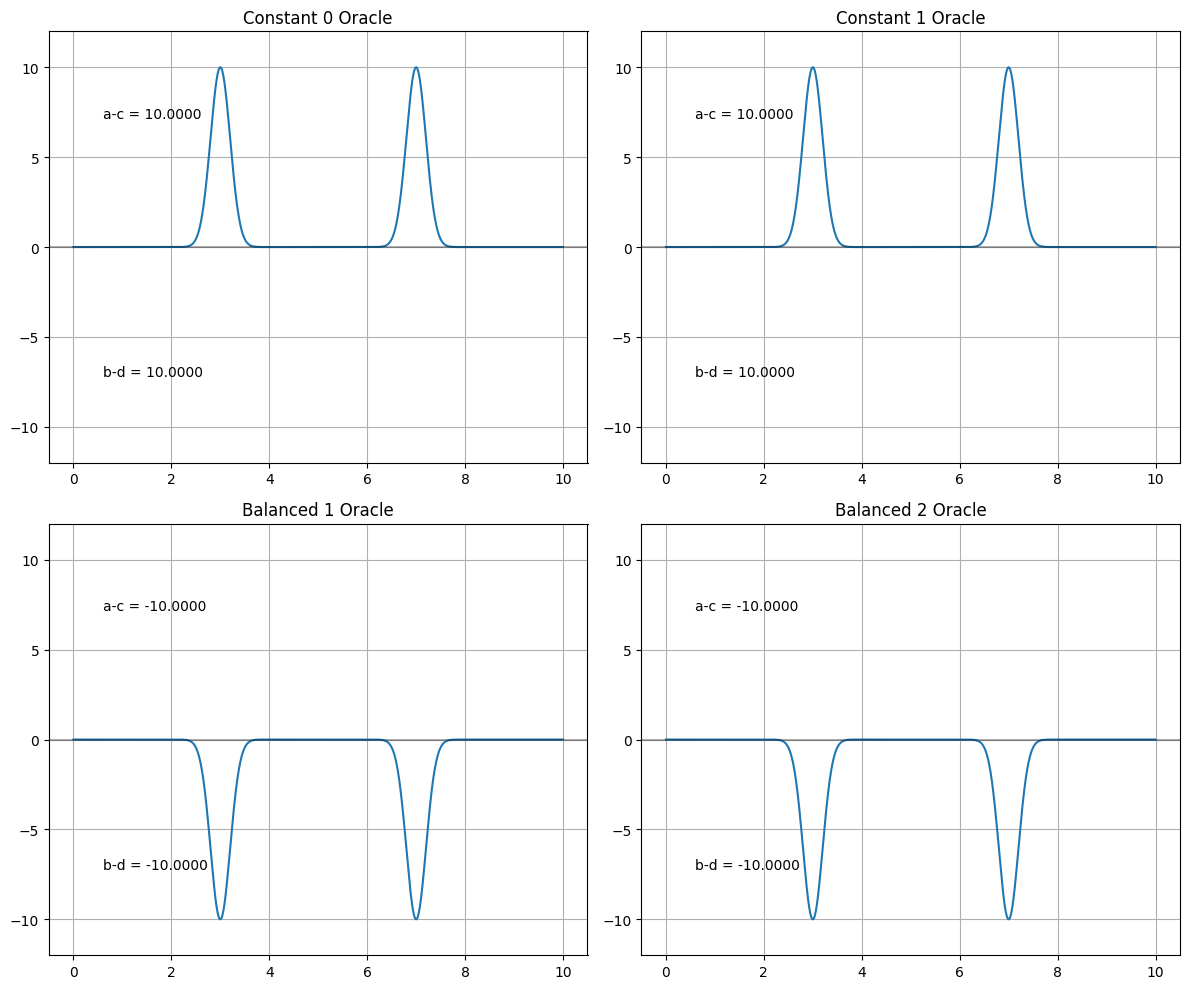


Summary of Deutsch-Jozsa Algorithm Proton Channel Peaks:
Oracle          | a-c        | b-d        | Expected   | Observed   | Correct   
----------------------------------------------------------------------
constant_0      | 10.0000    | 10.0000    | constant   | balanced   | False
constant_1      | 10.0000    | 10.0000    | constant   | balanced   | False
balanced_1      | -10.0000   | -10.0000   | balanced   | balanced   | True
balanced_2      | -10.0000   | -10.0000   | balanced   | balanced   | True


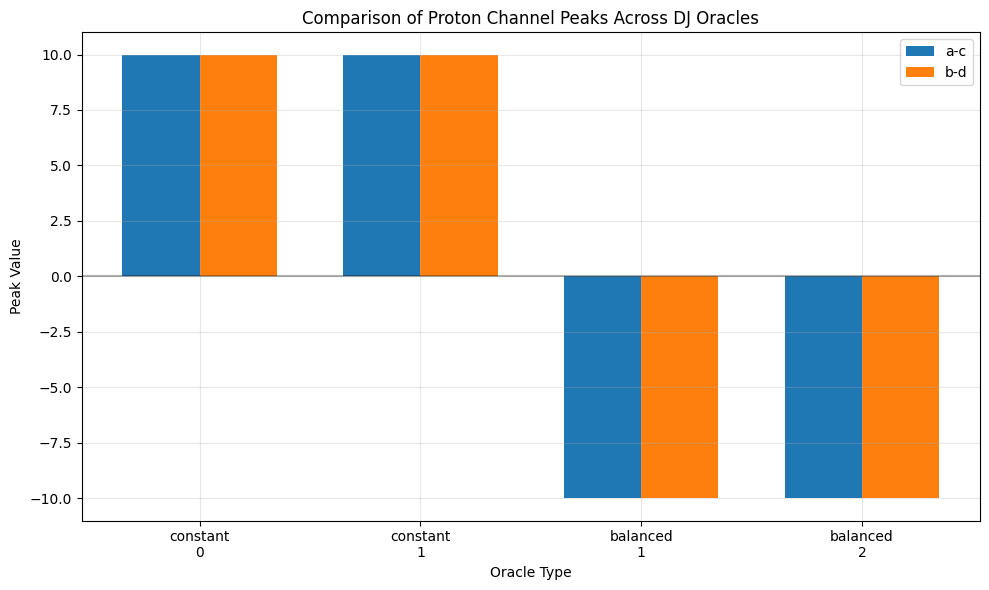

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, List, Dict

def analyze_dj_proton_peaks(thermal_matrix, verbose=True):
    """
    Analyzes proton channel peaks for all four cases of the Deutsch-Jozsa algorithm.
    
    Parameters:
    thermal_matrix: Input thermal matrix (4x4 diagonal)
    verbose: Whether to print detailed information
    
    Returns:
    Dictionary with results for each oracle
    """
    # Define the thermal matrix
    thermal = np.array(thermal_matrix)
    
    # Extract diagonal elements
    a = thermal[0][0]  # Top-left value
    b = thermal[1][1]  # Second diagonal value
    c = thermal[2][2]  # Third diagonal value (negative)
    d = thermal[3][3]  # Bottom-right value (negative)
    
    if verbose:
        print("Thermal Matrix (Full):")
        print(thermal)
        print("\nThermal Matrix Diagonal Elements:")
        print(f"a = {a}, b = {b}, c = {c}, d = {d}")
    
    # Define the basic gates needed for DJ algorithm
    I = np.eye(4)  # Identity 4x4
    
    # Define CNOT matrix as per the original code
    cnot = np.array([
        [1, 0, 0, 0],
        [0, 1, 0, 0],
        [0, 0, 0, 1],
        [0, 0, 1, 0]
    ])
    cnot_dag = np.array([
        [1, 0, 0, 0],
        [0, 0, 0, 1],
        [0, 0, 1, 0],
        [0, 1, 0, 0]
    ])
    
    # Define P1 and P2 as in the original code
    P1 = cnot_dag @ cnot
    P1_dag = P1.T
    
    P2 = cnot @ cnot_dag
    P2_dag = P2.T
    
    if verbose:
        print("\nP1 Matrix (cnot_dag @ cnot):")
        print(P1)
        print("\nP2 Matrix (cnot @ cnot_dag):")
        print(P2)
    
    # Define Hadamard for 1 qubit
    H_1qubit = (1/np.sqrt(2)) * np.array([
        [1, 1],
        [1, -1]
    ])
    
    # Tensor product to get Hadamard for first qubit (H ⊗ I)
    H_q0 = np.kron(H_1qubit, np.eye(2))
    
    # Tensor product to get Hadamard for second qubit (I ⊗ H)
    H_q1 = np.kron(np.eye(2), H_1qubit)
    
    # Double Hadamard on both qubits (H ⊗ H)
    H_both = H_q0 @ H_q1
    
    # X gate for second qubit
    X_q1 = np.array([
        [0, 1, 0, 0],
        [1, 0, 0, 0],
        [0, 0, 0, 1],
        [0, 0, 1, 0]
    ])
    
    # Define the oracle functions for Deutsch-Jozsa algorithm
    oracle_constant_0 = np.eye(4)
    oracle_constant_1 = X_q1
    oracle_balanced_1 = cnot
    oracle_balanced_2 = X_q1 @ cnot
    
    # Dictionary of all oracles
    oracles = {
        "constant_0": oracle_constant_0,
        "constant_1": oracle_constant_1,
        "balanced_1": oracle_balanced_1,
        "balanced_2": oracle_balanced_2
    }
    
    results = {}
    
    # Create a figure for plotting all oracle peaks
    plt.figure(figsize=(12, 10))
    
    # Create pseudo-pure |00⟩ state
    pseudopure_00 = (I @ thermal @ I + P1 @ thermal @ P1_dag + P2 @ thermal @ P2_dag)
    
    if verbose:
        print("\nPseudo-pure |00⟩ state matrix:")
        print(pseudopure_00)
    
    for i, (oracle_name, oracle) in enumerate(oracles.items(), 1):
        if verbose:
            print(f"\n{'='*50}")
            print(f"Analyzing {oracle_name} oracle")
            print(f"{'='*50}")
        
        # Apply DJ algorithm steps
        state = pseudopure_00.copy()
        state = X_q1 @ state @ X_q1  # Prepare |01⟩ state
        state = H_both @ state @ H_both
        state = oracle @ state @ oracle.T
        state = H_q0 @ state @ H_q0
        
        a_prime = state[0][0]
        b_prime = state[1][1]
        c_prime = state[2][2]
        d_prime = state[3][3]
        
        a_minus_c_prime = a_prime - c_prime
        b_minus_d_prime = b_prime - d_prime
        
        if verbose:
            print(f"\nResult State Matrix after DJ algorithm with {oracle_name}:")
            print(state)
            print(f"\nDiagonal elements: a={a_prime}, b={b_prime}, c={c_prime}, d={d_prime}")
            print(f"Proton Channel Peaks: a-c={a_minus_c_prime}, b-d={b_minus_d_prime}")
        
        results[oracle_name] = {
            "state": state,
            "diagonal": [a_prime, b_prime, c_prime, d_prime],
            "proton_peaks": [a_minus_c_prime, b_minus_d_prime]
        }
        
        plt.subplot(2, 2, i)
        plt.title(f"{oracle_name.replace('_', ' ').title()} Oracle")
        plot_peaks([a_minus_c_prime, b_minus_d_prime])
        plt.annotate(f"a-c = {a_minus_c_prime:.4f}", xy=(0.1, 0.8), xycoords='axes fraction')
        plt.annotate(f"b-d = {b_minus_d_prime:.4f}", xy=(0.1, 0.2), xycoords='axes fraction')
        
        expected = "constant" if "constant" in oracle_name else "balanced"
        observed = "constant" if abs(a_minus_c_prime) > abs(b_minus_d_prime) else "balanced"
        
        if verbose:
            print(f"Expected: {expected}, Observed: {observed}")
            print(f"Classification Correct: {expected == observed}")
    
    plt.tight_layout()
    plt.savefig('dj_proton_peaks.png')
    plt.show()
    
    print("\nSummary of Deutsch-Jozsa Algorithm Proton Channel Peaks:")
    print("="*70)
    print(f"{'Oracle':<15} | {'a-c':<10} | {'b-d':<10} | {'Expected':<10} | {'Observed':<10} | {'Correct':<10}")
    print("-"*70)
    
    for oracle_name, result in results.items():
        a_minus_c = result["proton_peaks"][0]
        b_minus_d = result["proton_peaks"][1]
        expected = "constant" if "constant" in oracle_name else "balanced"
        observed = "constant" if abs(a_minus_c) > abs(b_minus_d) else "balanced"
        correct = expected == observed
        
        print(f"{oracle_name:<15} | {a_minus_c:<10.4f} | {b_minus_d:<10.4f} | {expected:<10} | {observed:<10} | {correct}")
    
    print("="*70)
    
    return results


def plot_peaks(values):
    """Plot peaks based on values similar to those shown in the image"""
    x = np.linspace(0, 10, 1000)
    y = np.zeros_like(x)
    
    # Add first peak
    peak1_center = 3
    peak1_height = values[0]
    peak1 = peak1_height * np.exp(-0.5 * ((x - peak1_center) / 0.2) ** 2)
    
    # Add second peak
    peak2_center = 7
    peak2_height = values[1]
    peak2 = peak2_height * np.exp(-0.5 * ((x - peak2_center) / 0.2) ** 2)
    
    # Combine peaks
    y = peak1 + peak2
    
    plt.plot(x, y)
    plt.grid(True)
    plt.ylim(-max(abs(min(y)), abs(max(y)))*1.2, max(abs(min(y)), abs(max(y)))*1.2)
    plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)

# Define the thermal matrix (4x4 diagonal) as in the original code
thermal_matrix = np.array([
    [5, 0, 0, 0],
    [0, 3, 0, 0],
    [0, 0, -3, 0],
    [0, 0, 0, -5]
])

# Run the analysis
results = analyze_dj_proton_peaks(thermal_matrix, verbose=True)

# Create a separate figure to compare the proton peaks for all oracles
plt.figure(figsize=(10, 6))

# Extract peak values for plotting
oracle_names = list(results.keys())
a_minus_c_values = [results[name]["proton_peaks"][0] for name in oracle_names]
b_minus_d_values = [results[name]["proton_peaks"][1] for name in oracle_names]

# Plot a-c peaks (first peaks)
x = np.arange(len(oracle_names))
width = 0.35
plt.bar(x - width/2, a_minus_c_values, width, label='a-c')
plt.bar(x + width/2, b_minus_d_values, width, label='b-d')

plt.xlabel('Oracle Type')
plt.ylabel('Peak Value')
plt.title('Comparison of Proton Channel Peaks Across DJ Oracles')
plt.xticks(x, [name.replace('_', '\n') for name in oracle_names])
plt.legend()
plt.grid(True, alpha=0.3)

# Add a horizontal line at y=0
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)

plt.savefig('dj_proton_peaks_comparison.png')
plt.tight_layout()
plt.show()

In [2]:
import numpy as np
import qutip as qt
from qutip import Qobj
from typing import Tuple

class NMRGates:
    def __init__(self, j_coupling=100.0):
        """
        Initialize NMR gates with specified J-coupling parameter (in Hz).
        
        Args:
            j_coupling: The J-coupling constant between H and C nuclei in Hz
        """
        self.j_coupling = j_coupling
        
        # Define the Pauli matrices for a single qubit
        self.I = qt.qeye(2)
        self.X = qt.sigmax()
        self.Y = qt.sigmay()
        self.Z = qt.sigmaz()
        
        # Define the individual spin operators for H and C
        self.IX = qt.tensor(self.X, self.I)
        self.IY = qt.tensor(self.Y, self.I)
        self.IZ = qt.tensor(self.Z, self.I)
        self.XI = qt.tensor(self.I, self.X)
        self.YI = qt.tensor(self.I, self.Y)
        self.ZI = qt.tensor(self.I, self.Z)
        
        # Define the J-coupling operator
        self.ZZ = qt.tensor(self.Z, self.Z)
    
    def rx(self, angle: float, qubit: int) -> qt.Qobj:
        """
        Rotation around X axis for the specified qubit.
        
        Args:
            angle: Rotation angle in radians
            qubit: Qubit index (0 for H, 1 for C)
            
        Returns:
            The rotation operator as a QuTiP Qobj
        """
        # Create single-qubit rotation operator: exp(-i * angle/2 * X)
        cos_angle = np.cos(angle/2)
        sin_angle = -1j * np.sin(angle/2)
        rx_operator = cos_angle * self.I + sin_angle * self.X
        if qubit == 0:  # H qubit
            return qt.tensor(rx_operator, self.I)
        else:  # C qubit
            return qt.tensor(self.I, rx_operator)
    
    def ry(self, angle: float, qubit: int) -> qt.Qobj:
        """
        Rotation around Y axis for the specified qubit.
        
        Args:
            angle: Rotation angle in radians
            qubit: Qubit index (0 for H, 1 for C)
            
        Returns:
            The rotation operator as a QuTiP Qobj
        """
        # Create single-qubit rotation operator: exp(-i * angle/2 * Y)
        cos_angle = np.cos(angle/2)
        sin_angle = -1j * np.sin(angle/2)
        ry_operator = cos_angle * self.I + sin_angle * self.Y
        if qubit == 0:  # H qubit
            return qt.tensor(ry_operator, self.I)
        else:  # C qubit
            return qt.tensor(self.I, ry_operator)
    
    def rz(self, angle: float, qubit: int) -> qt.Qobj:
        """
        Rotation around Z axis for the specified qubit.
        
        Args:
            angle: Rotation angle in radians
            qubit: Qubit index (0 for H, 1 for C)
            
        Returns:
            The rotation operator as a QuTiP Qobj
        """
        # Create single-qubit rotation operator: exp(-i * angle/2 * Z)
        cos_angle = np.cos(angle/2)
        sin_angle = -1j * np.sin(angle/2)
        rz_operator = cos_angle * self.I + sin_angle * self.Z
        
        if qubit == 0:  # H qubit
            return qt.tensor(rz_operator, self.I)
        else:  # C qubit
            return qt.tensor(self.I, rz_operator)
    
    def j_evolution(self, time: float) -> qt.Qobj:
        """
        Evolution under J-coupling Hamiltonian for specified time.
        
        Args:
            time: Evolution time in seconds
            
        Returns:
            The evolution operator as a QuTiP Qobj
        """
        # J-coupling Hamiltonian: 2π * J * I_z^H * I_z^C
        hamiltonian = 2 * np.pi  * 0.25 * self.ZZ
        return (-1j * hamiltonian * time).expm()
    
    def x_gate(self, qubit: int) -> qt.Qobj:
        """
        Implements X gate on the specified qubit.
        
        Args:
            qubit: Qubit index (0 for H, 1 for C)
            
        Returns:
            The X gate operator as a QuTiP Qobj
        """
        return self.rx(np.pi, qubit)

    def y_gate(self, qubit: int) -> qt.Qobj:
        """
        Implements Y gate on the specified qubit.
        
        Args:
            qubit: Qubit index (0 for H, 1 for C)
            
        Returns:
            The Y gate operator as a QuTiP Qobj
        """
        return self.ry(np.pi, qubit)
    
    def hadamard(self, qubit: int) -> qt.Qobj:
        """
        Implements Hadamard gate on the specified qubit.
        
        Args:
            qubit: Qubit index (0 for H, 1 for C)
            
        Returns:
            The Hadamard gate operator as a QuTiP Qobj
        """
        # H = RX(π) * RY(π/2)
        return self.rx(np.pi, qubit) * self.ry(np.pi/2, qubit)
    
    def cnot(self) -> qt.Qobj:
        """
        Implements controlled-Z gate with H as control and C as target.
        
        Returns:
            The controlled-Z gate operator as a QuTiP Qobj
        """
        u1 = self.ry(np.pi/2, 0)  #pulse_90_y(target_qubit=1)

        # 1/4J_IS (J-coupling for duration 1/4)
        u2 = self.j_evolution(1/4)   #j_coupling(duration=0.25)
    
        # 180_x (180 degree pulse around X on both spins)
        u3 = self.rx(np.pi, 1)@self.rx(np.pi, 0)   #pulse_180_x(target_qubit=0) @ pulse_180_x(target_qubit=1)
    
        # 1/4J_IS (J-coupling for duration 1/4)
        u4 = self.j_evolution(1/4)      #j_coupling(duration=0.25)
    
        # 180_x (180 degree pulse around X on both spins)
        u5 = self.rx(np.pi, 1)@self.rx(np.pi, 0)  #pulse_180_x(target_qubit=0) @ pulse_180_x(target_qubit=1)
    
        # 90I_y (90 degree pulse around Y on first spin)
        u6 = self.ry(np.pi/2, 1)   #pulse_90_y(target_qubit=0)
    
        # 90I_x (90 degree pulse around X on first spin)
        u7 = self.rx(np.pi/2, 1)   #pulse_90_x(target_qubit=0)
    
        # 90_-y (90 degree pulse around -Y on both spins)
        u8 = self.ry(-np.pi/2, 1)@self.ry(-np.pi/2, 0)   #pulse_90_minus_y(target_qubit=0) @ pulse_90_minus_y(target_qubit=1)
    
        # 90S_±x (90 degree pulse around +X or -X on second spin)
        u9 = self.rx(np.pi/2, 0)   #pulse_90_x(target_qubit=1)

        ccnot = u9 @ u8 @ u7 @ u6 @ u5 @ u4 @ u3 @ u2 @ u1
        print(f"cnot:{ccnot}")
        return ccnot
    
    def controlled_z(self) -> qt.Qobj:
        """
        Implements CZ gate with H as control and C as target.
        
        Returns:
            The CZ gate operator as a QuTiP Qobj
        """
        # CZ = H_C * CZ * H_C
        h_c = self.hadamard(1)
        cn = self.cnot()
        #print(f"cz:{h_c @ cn @ h_c}")
        return h_c @ cn @ h_c
    
    def simulate_gate(self, gate: qt.Qobj, initial_state: qt.Qobj) -> qt.Qobj:
        """
        Simulates the application of a gate to an initial state.
        
        Args:
            gate: The gate to apply
            initial_state: The initial quantum state
            
        Returns:
            The final quantum state after applying the gate
        """
        return gate * initial_state
    
    def test_gates(self):
        """Test all implemented gates and verify their correctness."""
        # Create |00⟩ state
        state_00 = qt.tensor(qt.basis(2, 0), qt.basis(2, 0))
        
        # Test X gate on first qubit
        x_h_result = self.simulate_gate(self.x_gate(0), state_00)
        print("X gate on H qubit (|00⟩ → |10⟩):")
        print(x_h_result)
        
        # Test X gate on second qubit
        x_c_result = self.simulate_gate(self.x_gate(1), state_00)
        print("\nX gate on C qubit (|00⟩ → |01⟩):")
        print(x_c_result)
        
        # Test Hadamard on first qubit
        h_h_result = self.simulate_gate(self.hadamard(0), state_00)
        print("\nHadamard on H qubit (|00⟩ → |+0⟩):")
        print(h_h_result)
        
        # Test CNOT gate
        plus_state = (qt.basis(2, 0) + qt.basis(2, 1)).unit()
        test_state = qt.tensor(plus_state, qt.basis(2, 0))
        cnot_result = self.simulate_gate(self.cnot(), test_state)
        print("\nCNOT on |+0⟩:")
        print(cnot_result)
        
        # Test Controlled-Z gate
        state_11 = qt.tensor(qt.basis(2, 1), qt.basis(2, 1))
        cz_result = self.simulate_gate(self.controlled_z(), state_11)
        print("\nControlled-Z on |11⟩:")
        print(cz_result)


# Example usage
if __name__ == "__main__":
    # Create NMR gates with a J-coupling of 215 Hz
    nmr = NMRGates(j_coupling=215)
    
    # Test all gates
    nmr.test_gates()
    
    # Demonstrate using these gates in a simple circuit
    print("\nExample circuit: Prepare Bell state |Φ+⟩ = (|00⟩ + |11⟩)/√2")
    
    # Start with |00⟩
    state = qt.tensor(qt.basis(2, 0), qt.basis(2, 0))
    print(f"Initial state: {state}")
    
    # Apply H to the first qubit
    # state = nmr.simulate_gate(nmr.hadamard(0), state)
    # print(f"After H on qubit H: {state}")
    
    # Apply CNOT with H as control and C as target
    state = nmr.simulate_gate(nmr.cnot(), state)
    print(f"After CNOT: {state}")
    
    # Verify we have a Bell state
    density_matrix = state * state.dag()
    print(f"\nFinal density matrix:\n{density_matrix}")
    
    # Calculate fidelity with ideal Bell state
    ideal_bell = (qt.tensor(qt.basis(2, 0), qt.basis(2, 0)) + 
                  qt.tensor(qt.basis(2, 1), qt.basis(2, 1))).unit()
    fidelity = qt.fidelity(density_matrix, ideal_bell)
    print(f"Fidelity with ideal Bell state: {fidelity}")

X gate on H qubit (|00⟩ → |10⟩):
Quantum object: dims=[[2, 2], [1, 1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.+0.j]
 [0.+0.j]
 [0.-1.j]
 [0.+0.j]]

X gate on C qubit (|00⟩ → |01⟩):
Quantum object: dims=[[2, 2], [1, 1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.+0.j]
 [0.-1.j]
 [0.+0.j]
 [0.+0.j]]

Hadamard on H qubit (|00⟩ → |+0⟩):
Quantum object: dims=[[2, 2], [1, 1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.-0.70710678j]
 [0.+0.j        ]
 [0.-0.70710678j]
 [0.+0.j        ]]
cnot:Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 7.07106781e-01-7.07106781e-01j  0.00000000e+00+0.00000000e+00j
   1.43539982e-16+4.59869434e-17j  0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j -1.57009246e-16-3.25176795e-17j
   0.00000000e+00+0.00000000e+00j  7.07106781e-01-7.07106781e-01j]
 [ 3.25176795e-17+1.57009246e-16j  0.00000000e+00+0.00000000e+00j
   7.07106781e-01-7.07106781e-01j 